In [619]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries

In [620]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [621]:
# File path
folder = "/content/drive/MyDrive/Colab Notebooks/Credit Risk Nigerian Dataset/"

# Load the dataset
train_perf = pd.read_csv(folder + "trainperf.csv")
train_prev = pd.read_csv(folder + "trainprevloans.csv")
train_demo = pd.read_csv(folder + "traindemographics.csv")


print("Performance:", train_perf.shape)
print("Previous Loans:", train_prev.shape)
print("Demographics:", train_demo.shape)

Performance: (4368, 10)
Previous Loans: (18183, 12)
Demographics: (4346, 9)


In [622]:
# Display the first five rows
train_perf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good


In [623]:
train_prev.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


In [624]:
train_demo.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


In [625]:
train_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid     4368 non-null   object 
 1   systemloanid   4368 non-null   int64  
 2   loannumber     4368 non-null   int64  
 3   approveddate   4368 non-null   object 
 4   creationdate   4368 non-null   object 
 5   loanamount     4368 non-null   float64
 6   totaldue       4368 non-null   float64
 7   termdays       4368 non-null   int64  
 8   referredby     587 non-null    object 
 9   good_bad_flag  4368 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 341.4+ KB


In [626]:
train_prev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       18183 non-null  object 
 1   systemloanid     18183 non-null  int64  
 2   loannumber       18183 non-null  int64  
 3   approveddate     18183 non-null  object 
 4   creationdate     18183 non-null  object 
 5   loanamount       18183 non-null  float64
 6   totaldue         18183 non-null  float64
 7   termdays         18183 non-null  int64  
 8   closeddate       18183 non-null  object 
 9   referredby       1026 non-null   object 
 10  firstduedate     18183 non-null  object 
 11  firstrepaiddate  18183 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [627]:
train_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   object 
 1   birthdate                   4346 non-null   object 
 2   bank_account_type           4346 non-null   object 
 3   longitude_gps               4346 non-null   float64
 4   latitude_gps                4346 non-null   float64
 5   bank_name_clients           4346 non-null   object 
 6   bank_branch_clients         51 non-null     object 
 7   employment_status_clients   3698 non-null   object 
 8   level_of_education_clients  587 non-null    object 
dtypes: float64(2), object(7)
memory usage: 305.7+ KB


In [628]:
train_perf.isnull().sum()

,0
customerid,0
systemloanid,0
loannumber,0
approveddate,0
creationdate,0
loanamount,0
totaldue,0
termdays,0
referredby,3781
good_bad_flag,0


In [629]:
train_prev.isnull().sum()

,0
customerid,0
systemloanid,0
loannumber,0
approveddate,0
creationdate,0
loanamount,0
totaldue,0
termdays,0
closeddate,0
referredby,17157


In [630]:
train_demo.isnull().sum()

,0
customerid,0
birthdate,0
bank_account_type,0
longitude_gps,0
latitude_gps,0
bank_name_clients,0
bank_branch_clients,4295
employment_status_clients,648
level_of_education_clients,3759


In [631]:
print(train_perf.duplicated().sum())
print(train_prev.duplicated().sum())
print(train_demo.duplicated().sum())

0
0
12


# Had to inspect train_demo's duplicates

In [632]:
train_demo[train_demo.duplicated(keep=False)]

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
138,8a858fca5c35df2c015c39ad8695343e,1980-11-26 00:00:00.000000,Savings,3.352588,7.211089,GT Bank,NaN,Permanent,NaN
159,8a858fca5c35df2c015c39ad8695343e,1980-11-26 00:00:00.000000,Savings,3.352588,7.211089,GT Bank,NaN,Permanent,NaN
272,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
445,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30 00:00:00.000000,Savings,3.367008,6.497313,Sterling Bank,NaN,Permanent,NaN
517,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
750,8a858f965bb63a25015bbf63fd062e2e,1974-02-25 00:00:00.000000,Savings,3.936366,6.817958,Stanbic IBTC,NaN,Permanent,NaN
776,8a858f965bb63a25015bbf63fd062e2e,1974-02-25 00:00:00.000000,Savings,3.936366,6.817958,Stanbic IBTC,NaN,Permanent,NaN
798,8a858fc75cd62882015cdaf2f4311b3f,1975-10-27 00:00:00.000000,Savings,7.437607,9.088935,GT Bank,NaN,Permanent,NaN
1010,8a858fe65675195a015679452588279c,1982-08-01 00:00:00.000000,Savings,7.533646,9.046885,UBA,NaN,Permanent,NaN
1015,8a858fe65675195a015679452588279c,1982-08-01 00:00:00.000000,Savings,7.533646,9.046885,UBA,NaN,Permanent,NaN


In [633]:
train_demo = train_demo.drop_duplicates()

In [634]:
train_demo.shape

(4334, 9)

In [635]:
train_perf["good_bad_flag"].value_counts()

,count
good_bad_flag,
Good,3416
Bad,952


In [636]:
train_perf["good_bad_flag"].value_counts(normalize=True) * 100

,proportion
good_bad_flag,
Good,78.205128
Bad,21.794872


In [637]:
train_perf = train_perf[
    [
        "customerid",
        "loanamount",
        "termdays",
        "loannumber",
        "good_bad_flag"
    ]
]

In [638]:
train_demo = train_demo[
    [
        "customerid",
        "birthdate",
        "bank_account_type",
        "bank_name_clients",
        "employment_status_clients",
        "level_of_education_clients"
    ]
]

In [639]:
train_prev = train_prev[
    [
        "customerid",
        "loanamount",
        "termdays",
        "approveddate",
        "firstduedate",
        "firstrepaiddate"
    ]
]

In [640]:
train_demo["birthdate"] = pd.to_datetime(train_demo["birthdate"])

In [641]:
from datetime import datetime

today = datetime.today()

train_demo["Age"] = (
    today.year
    - train_demo["birthdate"].dt.year
)

In [642]:
train_demo.drop(columns="birthdate", inplace=True)

In [643]:
train_demo.head()

,customerid,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,Age
0,8a858e135cb22031015cbafc76964ebd,Savings,GT Bank,NaN,NaN,53
1,8a858e275c7ea5ec015c82482d7c3996,Savings,Sterling Bank,Permanent,NaN,40
2,8a858e5b5bd99460015bdc95cd485634,Savings,Fidelity Bank,NaN,NaN,39
3,8a858efd5ca70688015cabd1f1e94b55,Savings,GT Bank,Permanent,NaN,35
4,8a858e785acd3412015acd48f4920d04,Savings,GT Bank,Permanent,NaN,44


In [644]:
train_prev.head()

,customerid,loanamount,termdays,approveddate,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,10000.0,30,2016-08-15 18:22:40.000000,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,10000.0,30,2017-04-28 18:39:07.000000,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,20000.0,30,2017-03-05 10:56:25.000000,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,10000.0,15,2017-04-09 18:25:55.000000,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,10000.0,15,2017-06-17 09:29:57.000000,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


In [645]:
train_perf.head()

,customerid,loanamount,termdays,loannumber,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,30000.0,30,12,Good
1,8a85886e54beabf90154c0a29ae757c0,15000.0,30,2,Good
2,8a8588f35438fe12015444567666018e,20000.0,15,7,Good
3,8a85890754145ace015429211b513e16,10000.0,15,3,Good
4,8a858970548359cc0154883481981866,40000.0,30,9,Good


In [646]:
train_demo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4334 entries, 0 to 4345
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   customerid                  4334 non-null   object
 1   bank_account_type           4334 non-null   object
 2   bank_name_clients           4334 non-null   object
 3   employment_status_clients   3686 non-null   object
 4   level_of_education_clients  586 non-null    object
 5   Age                         4334 non-null   int32 
dtypes: int32(1), object(5)
memory usage: 220.1+ KB


In [647]:
train_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid     4368 non-null   object 
 1   loanamount     4368 non-null   float64
 2   termdays       4368 non-null   int64  
 3   loannumber     4368 non-null   int64  
 4   good_bad_flag  4368 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 170.8+ KB


In [648]:
train_prev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       18183 non-null  object 
 1   loanamount       18183 non-null  float64
 2   termdays         18183 non-null  int64  
 3   approveddate     18183 non-null  object 
 4   firstduedate     18183 non-null  object 
 5   firstrepaiddate  18183 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 852.5+ KB


# Feature Engineering

In [649]:
# Total Previous Loans
previous_loans = (
    train_prev.groupby("customerid")
    .size()
    .reset_index(name="total_previous_loans")
)

In [650]:
# Average Previous Loan Amount
avg_previous_loan = (
    train_prev.groupby("customerid")["loanamount"]
    .mean()
    .reset_index(name="avg_previous_loan")
)

In [651]:
# Maximum Previous Loan Amount
max_previous_loan = (
    train_prev.groupby("customerid")["loanamount"]
    .max()
    .reset_index(name="max_previous_loan")
)

In [652]:
# Average Loan Term
avg_previous_term = (
    train_prev.groupby("customerid")["termdays"]
    .mean()
    .reset_index(name="avg_previous_term")
)

In [653]:
# Convert the dates
date_columns = [
    "approveddate",
    "firstduedate",
    "firstrepaiddate"
]

for col in date_columns:
    train_prev[col] = pd.to_datetime(train_prev[col])

In [654]:
# Calculate Repayment Delay

# Negative means early payment.
# Positive means late payment.


train_prev["repayment_delay_days"] = (
    train_prev["firstrepaiddate"] -
    train_prev["firstduedate"]
).dt.days

In [655]:
# Average Repayment Delay
avg_delay = (
    train_prev.groupby("customerid")["repayment_delay_days"]
    .mean()
    .reset_index(name="avg_repayment_delay")
)

In [656]:
# Worst Repayment Delay
max_delay = (
    train_prev.groupby("customerid")["repayment_delay_days"]
    .max()
    .reset_index(name="max_repayment_delay")
)

# Merging all Engineering Feaures

In [657]:
loan_history = previous_loans

loan_history = loan_history.merge(avg_previous_loan, on="customerid")
loan_history = loan_history.merge(max_previous_loan, on="customerid")
loan_history = loan_history.merge(avg_previous_term, on="customerid")
loan_history = loan_history.merge(avg_delay, on="customerid")
loan_history = loan_history.merge(max_delay, on="customerid")

In [658]:
loan_history.head()

,customerid,total_previous_loans,avg_previous_loan,max_previous_loan,avg_previous_term,avg_repayment_delay,max_repayment_delay
0,8a1088a0484472eb01484669e3ce4e0b,1,10000.000000,10000.0,15.000000,6.000000,6
1,8a1a1e7e4f707f8b014f797718316cad,4,17500.000000,30000.0,37.500000,-0.250000,1
2,8a1a32fc49b632520149c3b8fdf85139,7,12857.142857,20000.0,19.285714,-0.428571,1
3,8a1eb5ba49a682300149c3c068b806c7,8,16250.000000,30000.0,33.750000,-3.125000,8
4,8a1edbf14734127f0147356fdb1b1eb2,2,10000.000000,10000.0,22.500000,-4.000000,0


In [659]:
# Create a late payment indicator
train_prev["late_payment"] = (
    train_prev["repayment_delay_days"] > 0
).astype(int)

In [660]:
late_payment_rate = (
    train_prev.groupby("customerid")["late_payment"]
    .mean()
    .reset_index(name="late_payment_rate")
)

In [661]:
loan_history = loan_history.merge(
    late_payment_rate,
    on="customerid",
    how="left"
)

In [662]:
loan_history.head()

,customerid,total_previous_loans,avg_previous_loan,max_previous_loan,avg_previous_term,avg_repayment_delay,max_repayment_delay,late_payment_rate
0,8a1088a0484472eb01484669e3ce4e0b,1,10000.000000,10000.0,15.000000,6.000000,6,1.000000
1,8a1a1e7e4f707f8b014f797718316cad,4,17500.000000,30000.0,37.500000,-0.250000,1,0.250000
2,8a1a32fc49b632520149c3b8fdf85139,7,12857.142857,20000.0,19.285714,-0.428571,1,0.142857
3,8a1eb5ba49a682300149c3c068b806c7,8,16250.000000,30000.0,33.750000,-3.125000,8,0.125000
4,8a1edbf14734127f0147356fdb1b1eb2,2,10000.000000,10000.0,22.500000,-4.000000,0,0.000000


# Merging Datasets

In [663]:
df = train_perf.merge(
    train_demo,
    on="customerid",
    how="left"
)

In [664]:
df = df.merge(
    loan_history,
    on="customerid",
    how="left"
)

In [665]:
df.head()

,customerid,loanamount,termdays,loannumber,good_bad_flag,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,Age,total_previous_loans,avg_previous_loan,max_previous_loan,avg_previous_term,avg_repayment_delay,max_repayment_delay,late_payment_rate
0,8a2a81a74ce8c05d014cfb32a0da1049,30000.0,30,12,Good,Other,Diamond Bank,Permanent,Post-Graduate,54.0,11.0,18181.818182,30000.0,30.0,-0.909091,39.0,0.272727
1,8a85886e54beabf90154c0a29ae757c0,15000.0,30,2,Good,Savings,GT Bank,Permanent,Graduate,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,20000.0,15,7,Good,Other,EcoBank,Permanent,NaN,42.0,6.0,10000.000000,10000.0,17.5,0.833333,30.0,0.166667
3,8a85890754145ace015429211b513e16,10000.0,15,3,Good,Savings,First Bank,Permanent,NaN,49.0,2.0,10000.000000,10000.0,22.5,7.500000,11.0,1.000000
4,8a858970548359cc0154883481981866,40000.0,30,9,Good,Other,GT Bank,Permanent,Primary,40.0,8.0,18750.000000,30000.0,37.5,-3.125000,-1.0,0.000000


In [666]:
df.shape

(4368, 17)

In [667]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4368 non-null   object 
 1   loanamount                  4368 non-null   float64
 2   termdays                    4368 non-null   int64  
 3   loannumber                  4368 non-null   int64  
 4   good_bad_flag               4368 non-null   object 
 5   bank_account_type           3269 non-null   object 
 6   bank_name_clients           3269 non-null   object 
 7   employment_status_clients   2776 non-null   object 
 8   level_of_education_clients  443 non-null    object 
 9   Age                         3269 non-null   float64
 10  total_previous_loans        4359 non-null   float64
 11  avg_previous_loan           4359 non-null   float64
 12  max_previous_loan           4359 non-null   float64
 13  avg_previous_term           4359 

# Handling Missing Values

In [668]:
df.isnull().sum()

,0
customerid,0
loanamount,0
termdays,0
loannumber,0
good_bad_flag,0
bank_account_type,1099
bank_name_clients,1099
employment_status_clients,1592
level_of_education_clients,3925
Age,1099


In [669]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [670]:
df["bank_account_type"] = df["bank_account_type"].fillna(
    df["bank_account_type"].mode()[0]
)

In [671]:
df["employment_status_clients"] = df["employment_status_clients"].fillna("Unknown")

In [672]:
loan_history_cols = [
    "total_previous_loans",
    "avg_previous_loan",
    "max_previous_loan",
    "avg_previous_term",
    "avg_repayment_delay",
    "max_repayment_delay",
    "late_payment_rate"
]

df[loan_history_cols] = df[loan_history_cols].fillna(0)

In [673]:
df.drop(columns=["level_of_education_clients"], inplace=True)

In [674]:
df.drop(columns=["customerid"], inplace=True)

In [675]:
df.drop(columns=["bank_name_clients"], inplace=True)

In [676]:
df.isnull().sum()

,0
loanamount,0
termdays,0
loannumber,0
good_bad_flag,0
bank_account_type,0
employment_status_clients,0
Age,0
total_previous_loans,0
avg_previous_loan,0
max_previous_loan,0


In [677]:
df["loannumber"].describe()

,loannumber
count,4368.000000
mean,5.172390
std,3.653569
min,2.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,27.000000


In [678]:
df["loannumber"].value_counts().sort_index()

,count
loannumber,
2,1393
3,670
4,443
5,326
6,247
7,252
8,220
9,180
10,191


In [679]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loanamount                 4368 non-null   float64
 1   termdays                   4368 non-null   int64  
 2   loannumber                 4368 non-null   int64  
 3   good_bad_flag              4368 non-null   object 
 4   bank_account_type          4368 non-null   object 
 5   employment_status_clients  4368 non-null   object 
 6   Age                        4368 non-null   float64
 7   total_previous_loans       4368 non-null   float64
 8   avg_previous_loan          4368 non-null   float64
 9   max_previous_loan          4368 non-null   float64
 10  avg_previous_term          4368 non-null   float64
 11  avg_repayment_delay        4368 non-null   float64
 12  max_repayment_delay        4368 non-null   float64
 13  late_payment_rate          4368 non-null   float

# Encoding

In [680]:
df["good_bad_flag"] = df["good_bad_flag"].map({
    "Good": 0,
    "Bad": 1
})

In [681]:
df["good_bad_flag"].value_counts()

,count
good_bad_flag,
0,3416
1,952


In [682]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Create encoders
le_bank = LabelEncoder()
le_emp = LabelEncoder()

# Fit on ORIGINAL text values
le_bank.fit(df["bank_account_type"])
le_emp.fit(df["employment_status_clients"])

# Save encoders for Streamlit
label_encoders = {
    "bank_account_type": le_bank,
    "employment_status_clients": le_emp
}

joblib.dump(label_encoders, "label_encoders.pkl")

# Now encode the dataframe
df["bank_account_type"] = le_bank.transform(df["bank_account_type"])
df["employment_status_clients"] = le_emp.transform(df["employment_status_clients"])

print(label_encoders.keys())

dict_keys(['bank_account_type', 'employment_status_clients'])


In [683]:
df.head()

,loanamount,termdays,loannumber,good_bad_flag,bank_account_type,employment_status_clients,Age,total_previous_loans,avg_previous_loan,max_previous_loan,avg_previous_term,avg_repayment_delay,max_repayment_delay,late_payment_rate
0,30000.0,30,12,0,1,1,54.0,11.0,18181.818182,30000.0,30.0,-0.909091,39.0,0.272727
1,15000.0,30,2,0,2,1,41.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,20000.0,15,7,0,1,1,42.0,6.0,10000.000000,10000.0,17.5,0.833333,30.0,0.166667
3,10000.0,15,3,0,2,1,49.0,2.0,10000.000000,10000.0,22.5,7.500000,11.0,1.000000
4,40000.0,30,9,0,1,1,40.0,8.0,18750.000000,30000.0,37.5,-3.125000,-1.0,0.000000


# Exploratory Data Analysis

In [684]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [685]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4368
Columns: 14


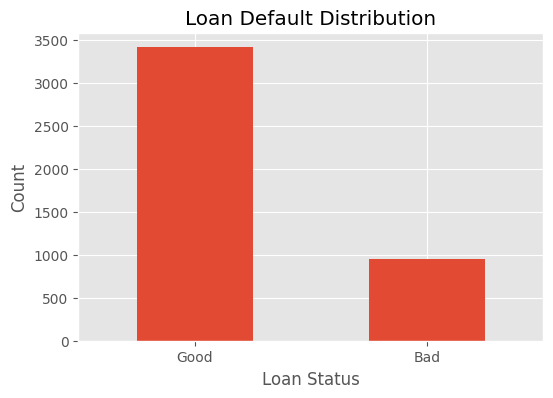

In [686]:
plt.figure(figsize=(6,4))

df["good_bad_flag"].value_counts().plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks([0,1],["Good","Bad"], rotation=0)

plt.show()

In [687]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loanamount,4368.0,17809.065934,10749.694571,10000.0,10000.000000,10000.000000,20000.000000,60000.000000
termdays,4368.0,29.261676,11.512519,15.0,30.000000,30.000000,30.000000,90.000000
loannumber,4368.0,5.172390,3.653569,2.0,2.000000,4.000000,7.000000,27.000000
good_bad_flag,4368.0,0.217949,0.412900,0.0,0.000000,0.000000,0.000000,1.000000
bank_account_type,4368.0,1.829441,0.403197,0.0,2.000000,2.000000,2.000000,2.000000
employment_status_clients,4368.0,3.065476,2.342608,0.0,1.000000,1.000000,6.000000,6.000000
Age,4368.0,41.680861,5.319452,30.0,39.000000,41.000000,44.000000,65.000000
total_previous_loans,4368.0,4.162775,3.655952,0.0,1.000000,3.000000,6.000000,26.000000
avg_previous_loan,4368.0,12882.906423,4849.816080,0.0,10000.000000,10000.000000,14285.714286,36666.666667
max_previous_loan,4368.0,16866.987179,10344.420451,0.0,10000.000000,10000.000000,20000.000000,60000.000000


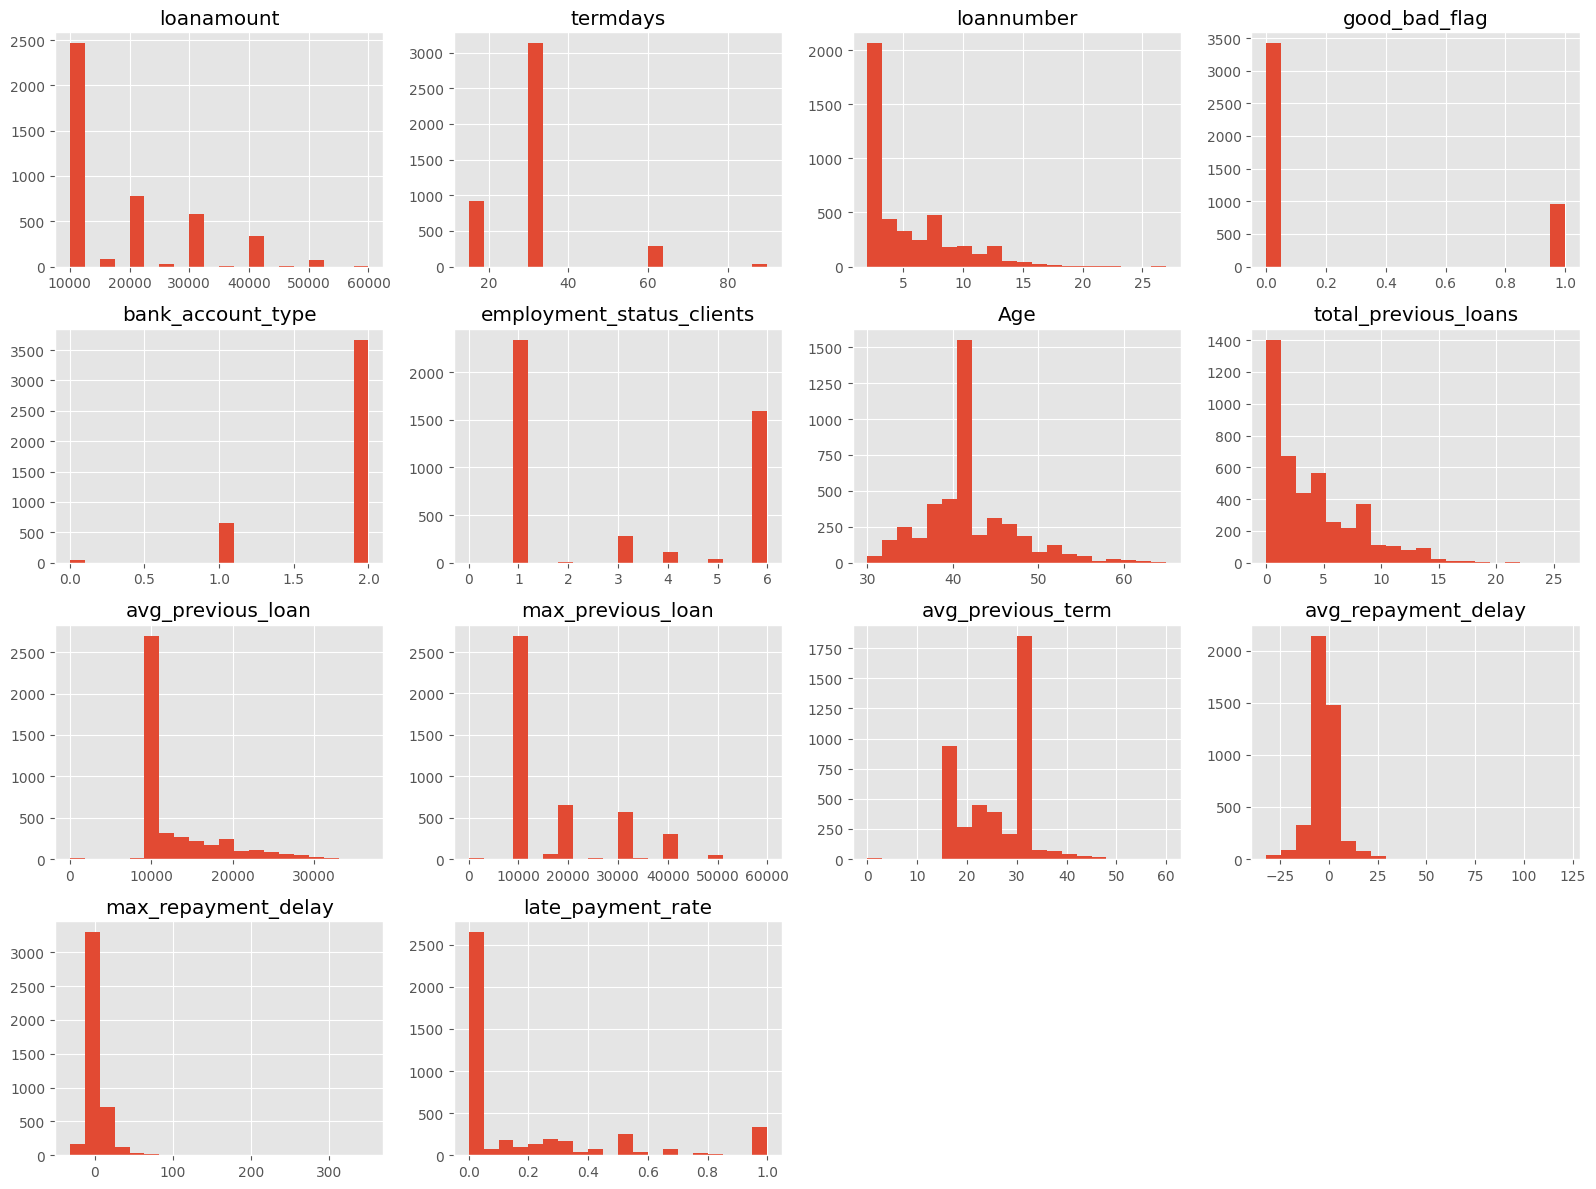

In [688]:
df.hist(figsize=(16,12), bins=20)

plt.tight_layout()
plt.show()

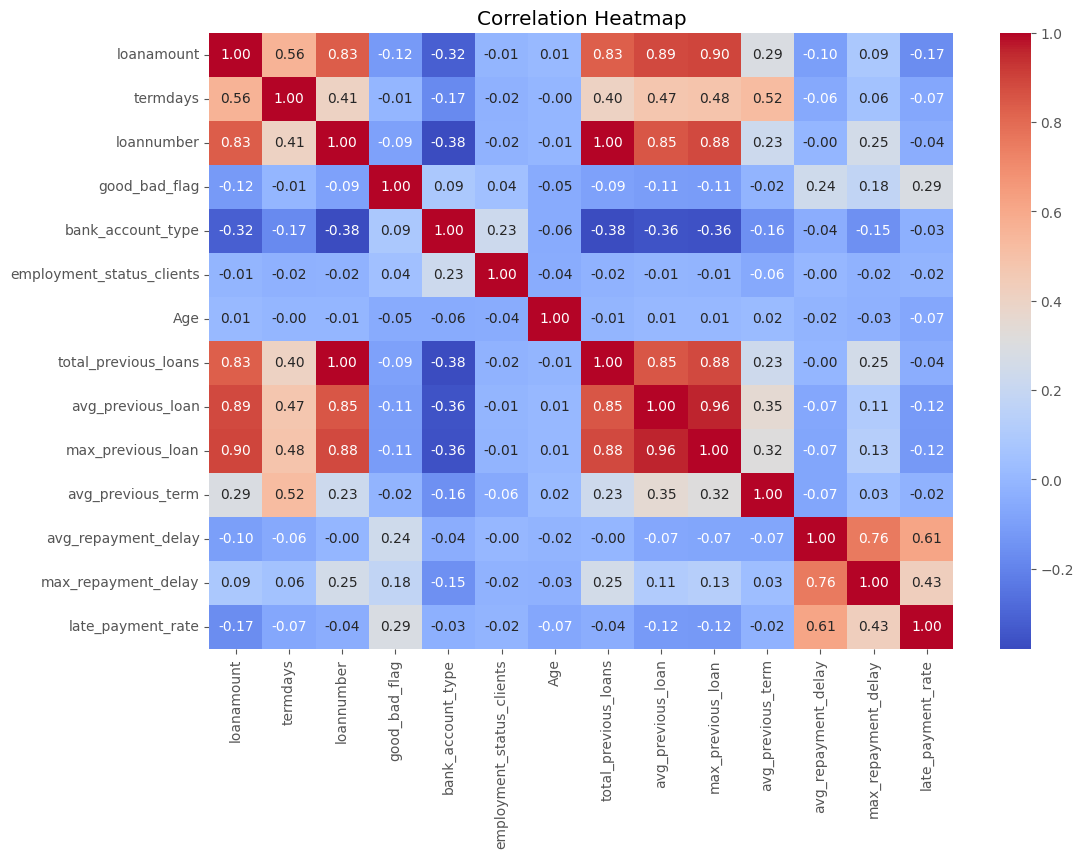

In [689]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

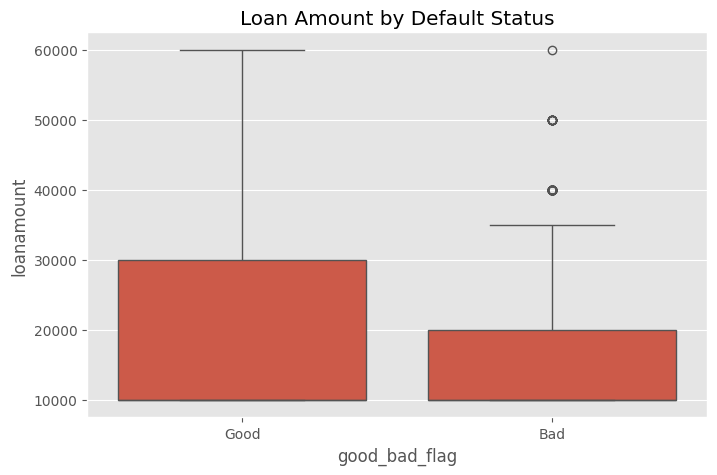

In [690]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="good_bad_flag",
    y="loanamount",
    data=df
)

plt.xticks([0,1],["Good","Bad"])

plt.title("Loan Amount by Default Status")

plt.show()

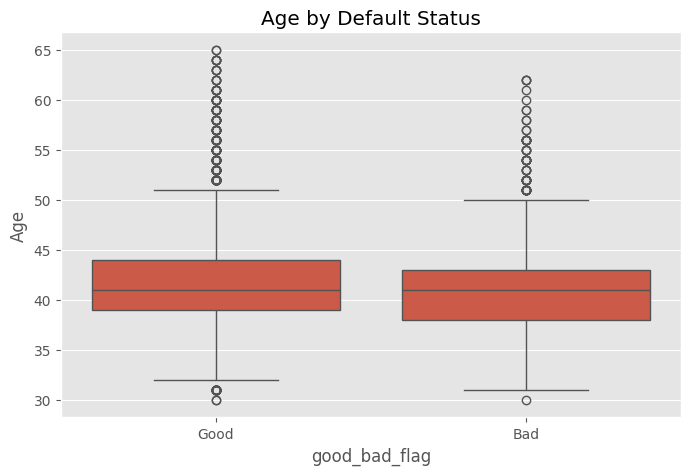

In [691]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="good_bad_flag",
    y="Age",
    data=df
)

plt.xticks([0,1],["Good","Bad"])

plt.title("Age by Default Status")

plt.show()

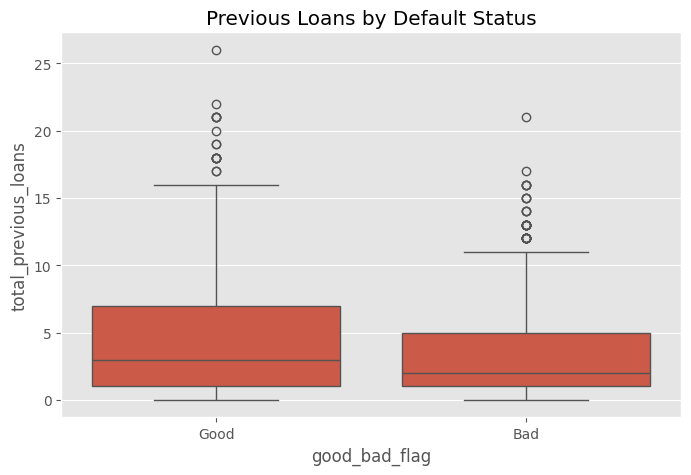

In [692]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="good_bad_flag",
    y="total_previous_loans",
    data=df
)

plt.xticks([0,1],["Good","Bad"])

plt.title("Previous Loans by Default Status")

plt.show()

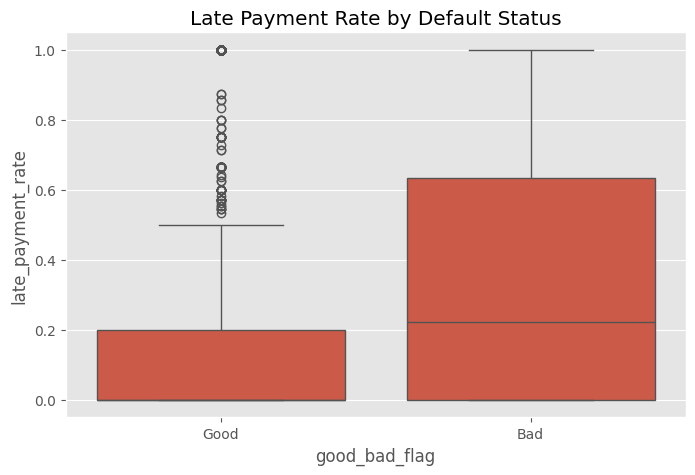

In [693]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="good_bad_flag",
    y="late_payment_rate",
    data=df
)

plt.xticks([0,1],["Good","Bad"])

plt.title("Late Payment Rate by Default Status")

plt.show()

# Training

In [694]:
# Features
X = df.drop("good_bad_flag", axis=1)

# Target
y = df["good_bad_flag"]

print(X.shape)
print(y.shape)

(4368, 13)
(4368,)


In [695]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3494, 13)
(874, 13)


In [696]:
print(columns)

['loanamount', 'termdays', 'loannumber', 'bank_account_type', 'employment_status_clients', 'Age', 'total_previous_loans', 'avg_previous_loan', 'max_previous_loan', 'avg_previous_term', 'avg_repayment_delay', 'max_repayment_delay', 'late_payment_rate']


In [697]:
print(X_train.columns.tolist())

['loanamount', 'termdays', 'loannumber', 'bank_account_type', 'employment_status_clients', 'Age', 'total_previous_loans', 'avg_previous_loan', 'max_previous_loan', 'avg_previous_term', 'avg_repayment_delay', 'max_repayment_delay', 'late_payment_rate']


In [698]:
print(scaler.feature_names_in_)

['loanamount' 'termdays' 'loannumber' 'Age' 'total_previous_loans'
 'avg_previous_loan' 'max_previous_loan' 'avg_previous_term'
 'avg_repayment_delay' 'max_repayment_delay' 'late_payment_rate']


# Scaling numerical Columns

In [699]:
numerical_cols = [
    "loanamount",
    "termdays",
    "loannumber",
    "Age",
    "total_previous_loans",
    "avg_previous_loan",
    "max_previous_loan",
    "avg_previous_term",
    "avg_repayment_delay",
    "max_repayment_delay",
    "late_payment_rate"
]

In [700]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [701]:
X_train_scaled.head()

,loanamount,termdays,loannumber,bank_account_type,employment_status_clients,Age,total_previous_loans,avg_previous_loan,max_previous_loan,avg_previous_term,avg_repayment_delay,max_repayment_delay,late_payment_rate
26,0.197904,0.051549,-0.324453,2,1,-1.417957,-0.321333,-0.592709,-0.662727,-1.470350,-0.122161,-0.187067,-0.610781
983,2.051731,0.051549,2.413145,2,6,-0.113889,2.414380,2.591634,2.237777,-0.313871,-0.665348,-0.187067,-0.610781
3402,-0.729009,0.051549,2.413145,2,6,-0.113889,2.414380,0.999462,1.270942,-0.148659,0.087550,1.658367,0.927112
466,1.124818,0.051549,1.044346,2,6,-0.113889,1.046523,0.442203,0.304107,-1.470350,-0.194787,1.065192,-0.194268
3934,-0.729009,-1.225836,-0.324453,2,1,1.190180,-0.321333,-0.592709,-0.662727,-0.754434,-0.122161,-0.121159,0.499920


# Evaluate the Metrics

In [702]:
results = []

In [703]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


def evaluate_model(model_name, model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

    return y_pred, y_prob

# Train Logistic Regression

In [704]:
evaluate_model(
    "Logistic Regression",
    log_model,
    X_test_scaled,
    y_test
)

Logistic Regression
Accuracy : 0.7254
Precision: 0.3984
Recall   : 0.5158
F1 Score : 0.4495
ROC AUC  : 0.7197

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.78      0.82       684
           1       0.40      0.52      0.45       190

    accuracy                           0.73       874
   macro avg       0.63      0.65      0.63       874
weighted avg       0.75      0.73      0.74       874


Confusion Matrix
[[536 148]
 [ 92  98]]


(array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
        0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 

# Decision Tree

In [705]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [706]:
evaluate_model(
    "Decision Tree",
    dt_model,
    X_test,
    y_test
)

Decision Tree
Accuracy : 0.7082
Precision: 0.3430
Recall   : 0.3737
F1 Score : 0.3577
ROC AUC  : 0.5920

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       684
           1       0.34      0.37      0.36       190

    accuracy                           0.71       874
   macro avg       0.58      0.59      0.58       874
weighted avg       0.72      0.71      0.71       874


Confusion Matrix
[[548 136]
 [119  71]]


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 

# RandomForestclassifier

In [707]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=400, n_jobs=-1, random_state=42)

In [708]:
evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

Random Forest
Accuracy : 0.7586
Precision: 0.4478
Recall   : 0.4737
F1 Score : 0.4604
ROC AUC  : 0.7087

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       684
           1       0.45      0.47      0.46       190

    accuracy                           0.76       874
   macro avg       0.65      0.66      0.65       874
weighted avg       0.76      0.76      0.76       874


Confusion Matrix
[[573 111]
 [100  90]]


(array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 

# KNN

In [709]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [710]:
evaluate_model(
    "KNN",
    knn_model,
    X_test_scaled,
    y_test
)

KNN
Accuracy : 0.7586
Precision: 0.3871
Recall   : 0.1895
F1 Score : 0.2544
ROC AUC  : 0.6442

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       684
           1       0.39      0.19      0.25       190

    accuracy                           0.76       874
   macro avg       0.59      0.55      0.56       874
weighted avg       0.71      0.76      0.73       874


Confusion Matrix
[[627  57]
 [154  36]]


(array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 


# Suppport Vector Mchine
> Add blockquote



In [711]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [712]:
evaluate_model(
    "SVM",
    svm_model,
    X_test_scaled,
    y_test
)

SVM
Accuracy : 0.7300
Precision: 0.4073
Recall   : 0.5316
F1 Score : 0.4612
ROC AUC  : 0.7115

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       684
           1       0.41      0.53      0.46       190

    accuracy                           0.73       874
   macro avg       0.63      0.66      0.64       874
weighted avg       0.76      0.73      0.74       874


Confusion Matrix
[[537 147]
 [ 89 101]]


(array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 

# Naive Bayes

In [713]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [714]:
evaluate_model(
    "Naive Bayes",
    nb_model,
    X_test_scaled,
    y_test
)

Naive Bayes
Accuracy : 0.7792
Precision: 0.4891
Recall   : 0.3526
F1 Score : 0.4098
ROC AUC  : 0.7245

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       684
           1       0.49      0.35      0.41       190

    accuracy                           0.78       874
   macro avg       0.66      0.63      0.64       874
weighted avg       0.76      0.78      0.77       874


Confusion Matrix
[[614  70]
 [123  67]]


(array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# XGBOOST

In [715]:
!pip install xgboost

In [716]:
from xgboost import XGBClassifier

scale_pos_weight = 3416 / 952

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=3.59,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [717]:
evaluate_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)

XGBoost
Accuracy : 0.7277
Precision: 0.4032
Recall   : 0.5263
F1 Score : 0.4566
ROC AUC  : 0.6991

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       684
           1       0.40      0.53      0.46       190

    accuracy                           0.73       874
   macro avg       0.63      0.65      0.64       874
weighted avg       0.76      0.73      0.74       874


Confusion Matrix
[[536 148]
 [ 90 100]]


(array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 

In [718]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,SVM,0.729977,0.407258,0.531579,0.461187,0.711519
2,Random Forest,0.758581,0.447761,0.473684,0.460358,0.708726
6,XGBoost,0.727689,0.403226,0.526316,0.456621,0.699065
0,Logistic Regression,0.725400,0.398374,0.515789,0.449541,0.719668
5,Naive Bayes,0.779176,0.489051,0.352632,0.409786,0.724469
1,Decision Tree,0.708238,0.342995,0.373684,0.357683,0.592048
3,KNN,0.758581,0.387097,0.189474,0.254417,0.644206


In [719]:
results_df.to_csv("model_comparison_results.csv", index=False)

In [720]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,avg_repayment_delay,0.219551
11,max_repayment_delay,0.163958
12,late_payment_rate,0.138867
5,Age,0.101787
9,avg_previous_term,0.070775
7,avg_previous_loan,0.062816
2,loannumber,0.048211
6,total_previous_loans,0.046507
1,termdays,0.037200
4,employment_status_clients,0.035866


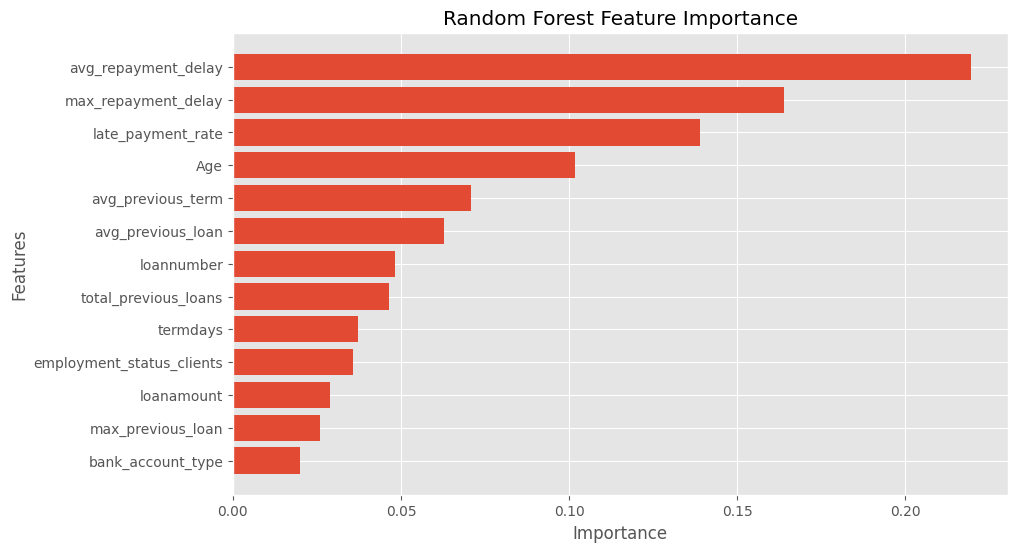

In [721]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [722]:
y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

# 5-Fold Cross Validation

In [723]:
from sklearn.model_selection import cross_val_score

In [724]:
cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.77968526 0.74964235 0.75536481 0.74391989 0.76361032]
Average CV Accuracy: 0.7584445236953322
Standard Deviation: 0.01245618381442365


In [725]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_results

,Fold,Accuracy
0,1,0.779685
1,2,0.749642
2,3,0.755365
3,4,0.743920
4,5,0.763610


In [726]:
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Mean Accuracy: 0.7584
Standard Deviation: 0.0125


# Saving Models and other necessary files

In [727]:
import joblib

joblib.dump(rf_model, "best_model.pkl")

['best_model.pkl']

In [728]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [729]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [730]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [731]:
import os

os.listdir()

['.config',
 'cloudflared-linux-amd64.deb.4',
 'cloudflared',
 'cloudflared-linux-amd64.deb',
 'scaler.pkl',
 'drive',
 'best_model.pkl',
 'label_encoders.pkl',
 'logs.txt',
 'cloudflared-linux-amd64.deb.2',
 'cloudflared-linux-amd64.deb.3',
 'LoanDefaultApp.py',
 'cloudflared-linux-amd64.deb.1',
 'model_comparison_results.csv',
 'columns.pkl',
 'sample_data']

In [732]:
!pip install streamlit -q
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 5s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [733]:
import streamlit as st
import pandas as pd
import joblib

In [734]:
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
columns = joblib.load("columns.pkl")
label_encoders = joblib.load("label_encoders.pkl")

In [735]:
%%writefile LoanDefaultApp.py

# ============================================================
# NIGERIAN LOAN DEFAULT PREDICTION SYSTEM
# Random Forest Classifier
# ============================================================

import streamlit as st
import pandas as pd
import joblib

# ============================================================
# LOAD TRAINED FILES
# ============================================================

model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
columns = joblib.load("columns.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Nigerian Loan Default Prediction System",
    page_icon="🏦",
    layout="wide"
)

# ============================================================
# HEADER
# ============================================================

st.title("🏦 Nigerian Loan Default Prediction System")

st.markdown("""
This application predicts the likelihood that a loan applicant will default before
loan approval using a **Random Forest Machine Learning Model** trained on a
Nigerian loan dataset.

The prediction is intended to support loan officers during the credit assessment
process.
""")

st.divider()

# ============================================================
# APPLICANT INFORMATION
# ============================================================

left_col, right_col = st.columns(2)

with left_col:

    st.subheader("👤 Applicant Information")

    Age = st.slider(
        "Age",
        min_value=18,
        max_value=80,
        value=35
    )

    employment_status_clients = st.selectbox(
        "Employment Status",
        label_encoders["employment_status_clients"].classes_
    )

    bank_account_type = st.selectbox(
        "Bank Account Type",
        label_encoders["bank_account_type"].classes_
    )

with right_col:

    st.subheader("💰 Loan Information")

    loanamount = st.number_input(
        "Loan Amount (₦)",
        min_value=1000.0,
        value=10000.0,
        step=1000.0
    )

    termdays = st.selectbox(
        "Loan Term (Days)",
        [15, 30, 60, 90]
    )

    loannumber = st.number_input(
        "Current Loan Number",
        min_value=1,
        value=2
    )

st.divider()

# ============================================================
# PREVIOUS LOAN HISTORY
# ============================================================

st.subheader("📊 Previous Loan History")

first_time = st.checkbox(
    "This applicant is a First-time Borrower",
    value=False
)

if first_time:

    total_previous_loans = 0
    avg_previous_loan = 0.0
    max_previous_loan = 0.0
    avg_previous_term = 0.0
    avg_repayment_delay = 0.0
    max_repayment_delay = 0.0
    late_payment_rate = 0.0

    st.info(
        "Previous loan history has been automatically set to zero because this applicant is a first-time borrower."
    )

else:

    col1, col2 = st.columns(2)

    with col1:

        total_previous_loans = st.number_input(
            "Total Previous Loans",
            min_value=0,
            value=1
        )

        avg_previous_loan = st.number_input(
            "Average Previous Loan Amount (₦)",
            min_value=0.0,
            value=10000.0
        )

        max_previous_loan = st.number_input(
            "Maximum Previous Loan Amount (₦)",
            min_value=0.0,
            value=10000.0
        )

        avg_previous_term = st.number_input(
            "Average Previous Loan Term (Days)",
            min_value=0.0,
            value=30.0
        )

    with col2:

        avg_repayment_delay = st.number_input(
            "Average Repayment Delay (Days)",
            value=0.0
        )

        max_repayment_delay = st.number_input(
            "Maximum Repayment Delay (Days)",
            value=0.0
        )

        late_payment_rate = st.slider(
            "Late Payment Rate",
            min_value=0.0,
            max_value=1.0,
            value=0.0
        )

st.divider()

# ============================================================
# PREDICT BUTTON
# ============================================================

predict = st.button(
    "🔍 Predict Loan Risk",
    use_container_width=True
)

if predict:

    # Save original inputs for summary later
    original_data = {
        "Loan Amount (₦)": loanamount,
        "Loan Term (Days)": termdays,
        "Current Loan Number": loannumber,
        "Age": Age,
        "Employment Status": employment_status_clients,
        "Bank Account Type": bank_account_type,
        "First-time Borrower": "Yes" if first_time else "No",
        "Total Previous Loans": total_previous_loans,
        "Average Previous Loan": avg_previous_loan,
        "Maximum Previous Loan": max_previous_loan,
        "Average Previous Loan Term": avg_previous_term,
        "Average Repayment Delay": avg_repayment_delay,
        "Maximum Repayment Delay": max_repayment_delay,
        "Late Payment Rate": late_payment_rate
    }

    # Encode categorical variables
    bank_account_type_encoded = label_encoders[
        "bank_account_type"
    ].transform([bank_account_type])[0]

    employment_status_encoded = label_encoders[
        "employment_status_clients"
    ].transform([employment_status_clients])[0]

    # Create dataframe
    input_data = pd.DataFrame({

        "loanamount": [loanamount],
        "termdays": [termdays],
        "loannumber": [loannumber],
        "bank_account_type": [bank_account_type_encoded],
        "employment_status_clients": [employment_status_encoded],
        "Age": [Age],
        "total_previous_loans": [total_previous_loans],
        "avg_previous_loan": [avg_previous_loan],
        "max_previous_loan": [max_previous_loan],
        "avg_previous_term": [avg_previous_term],
        "avg_repayment_delay": [avg_repayment_delay],
        "max_repayment_delay": [max_repayment_delay],
        "late_payment_rate": [late_payment_rate]

    })

    # Ensure column order matches training
    input_data = input_data[columns]

    # ============================================================
    # SCALE ONLY THE NUMERICAL FEATURES
    # ============================================================

    numeric_columns = [
        "loanamount",
        "termdays",
        "loannumber",
        "Age",
        "total_previous_loans",
        "avg_previous_loan",
        "max_previous_loan",
        "avg_previous_term",
        "avg_repayment_delay",
        "max_repayment_delay",
        "late_payment_rate"
    ]

    # Make a copy of the dataframe
    input_scaled = input_data.copy()

    # Scale ONLY the numerical columns
    input_scaled[numeric_columns] = scaler.transform(
        input_scaled[numeric_columns]
    )

    # ============================================================
    # MODEL PREDICTION
    # ============================================================

    prediction = model.predict(input_scaled)[0]

    probability = model.predict_proba(input_scaled)[0]

    probability_good = probability[0]
    probability_default = probability[1]

    # ============================================================
    # RISK CLASSIFICATION
    # ============================================================

    if probability_default < 0.30:

        risk = "🟢 LOW RISK"

        recommendation = (
            "The applicant presents a low probability of default. "
            "The loan may be approved under the institution's normal "
            "credit approval procedures."
        )

        risk_color = "green"

    elif probability_default < 0.60:

        risk = "🟡 MODERATE RISK"

        recommendation = (
            "The applicant presents a moderate level of credit risk. "
            "Additional income verification, guarantors or collateral "
            "should be considered before loan approval."
        )

        risk_color = "orange"

    else:

        risk = "🔴 HIGH RISK"

        recommendation = (
            "The applicant presents a high probability of default. "
            "The loan should only be considered after comprehensive "
            "credit assessment and additional financial verification."
        )

        risk_color = "red"

    # ============================================================
    # DISPLAY RESULTS
    # ============================================================

    st.success("Prediction Completed Successfully")

    st.divider()

    metric1, metric2, metric3 = st.columns(3)

    with metric1:

        st.metric(
            label="Repayment Probability",
            value=f"{probability_good * 100:.2f}%"
        )

    with metric2:

        st.metric(
            label="Default Probability",
            value=f"{probability_default * 100:.2f}%"
        )

    with metric3:

        if prediction == 0:
            st.success("✅ GOOD CUSTOMER")

        else:
            st.error("❌ LIKELY TO DEFAULT")

    st.divider()

    st.subheader("Risk Assessment")

    if risk_color == "green":
        st.success(risk)

    elif risk_color == "orange":
        st.warning(risk)

    else:
        st.error(risk)

    st.info(recommendation)

        # ============================================================
    # APPLICANT SUMMARY
    # ============================================================

    st.divider()

    st.subheader("Applicant Summary")

    summary_df = pd.DataFrame(
        list(original_data.items()),
        columns=["Feature", "Value"]
    )

    st.dataframe(
        summary_df,
        use_container_width=True,
        hide_index=True
    )

    # ============================================================
    # LOAN DECISION SUMMARY
    # ============================================================

    st.divider()

    st.subheader("Loan Decision Summary")

    decision = pd.DataFrame({

        "Prediction": [
            "Good Customer"
            if prediction == 0
            else "Likely to Default"
        ],

        "Risk Level": [risk],

        "Repayment Probability (%)": [
            round(probability_good * 100, 2)
        ],

        "Default Probability (%)": [
            round(probability_default * 100, 2)
        ]

    })

    st.dataframe(
        decision,
        use_container_width=True,
        hide_index=True
    )

    # ============================================================
    # DOWNLOAD RESULTS
    # ============================================================

    csv = decision.to_csv(index=False).encode("utf-8")

    st.download_button(
        label="📥 Download Prediction Report",
        data=csv,
        file_name="loan_prediction_result.csv",
        mime="text/csv",
        use_container_width=True
    )

    # ============================================================
    # MODEL INFORMATION
    # ============================================================

    with st.expander("Model Information"):

        st.markdown("""
### Machine Learning Model

- **Algorithm:** Random Forest Classifier
- **Target Variable:** Loan Default (Good / Bad)
- **Prediction Method:** Probability Estimation (`predict_proba`)
- **Feature Scaling:** StandardScaler (Numerical Features Only)
- **Categorical Encoding:** Label Encoding

### Input Features

- Loan Amount
- Loan Term
- Current Loan Number
- Age
- Employment Status
- Bank Account Type
- Total Previous Loans
- Average Previous Loan Amount
- Maximum Previous Loan Amount
- Average Previous Loan Term
- Average Repayment Delay
- Maximum Repayment Delay
- Late Payment Rate

The model estimates the probability that an applicant will default on a loan before approval.
""")

# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
"""
**Nigerian Loan Default Prediction System**

Developed as an undergraduate research project using Machine Learning.

**Model:** Random Forest Classifier

This application provides decision support for loan approval by estimating an applicant's probability of default. Predictions should complement professional credit assessment and should not be used as the sole basis for lending decisions.
"""
)

Overwriting LoanDefaultApp.py


In [736]:
import os

print(os.listdir())

['.config', 'cloudflared-linux-amd64.deb.4', 'cloudflared', 'cloudflared-linux-amd64.deb', 'scaler.pkl', 'drive', 'best_model.pkl', 'label_encoders.pkl', 'logs.txt', 'cloudflared-linux-amd64.deb.2', 'cloudflared-linux-amd64.deb.3', 'LoanDefaultApp.py', 'cloudflared-linux-amd64.deb.1', 'model_comparison_results.csv', 'columns.pkl', 'sample_data']


In [738]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

--2026-07-27 17:19:56--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64.deb [following]
--2026-07-27 17:19:56--  https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/2f835d85-8b95-40a5-8ff2-e6506a727970?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-27T18%3A18%3A21Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&

In [739]:
!streamlit run LoanDefaultApp.py &>/content/logs.txt &

In [740]:
!cloudflared tunnel --url http://localhost:8501

2026-07-27T17:20:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-27T17:20:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-27T17:20:05Z INF +--------------------------------------------------------------------------------------------+
2026-07-27T17:20:05Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-27T17:20:05Z INF |  https://upon-treasury-brooklyn-namespace.trycloudflar

In [744]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
xgboost

Overwriting requirements.txt
